# Combined 230K union — dataset deep dive

Profiles the **combined labeled router union** (`cascade ∪ v2 ∪ v3 ∪ v3_aug` ≈ 233K rows) —
the training population assembled inside `encoder_router_os_distill_relabel_probe.ipynb`, here
treated as a dataset in its own right. Four dimensions:

1. **Lanes** — per-dataset row counts and their dense/sparse mix.
2. **Dense/sparse distribution** — top-scoring-route mix overall, by source, by lane.
3. **Cells** — archetype (`composition.cells.CELLS`) coverage.
4. **Taxonomy features** — per-feature fire-rates from the stored feature catalog.

**Caveat:** cells and taxonomy features are read from the stored feature catalog
(`data/feature_table/catalog.parquet`). ~54% of union rows are catalog-indexed (the natural
corpus); the synthetic/augmented rows are not, so sections 3–4 report over the catalog-present
subset. Lanes and dense/sparse (1–2) cover the full union. Read-only: no live extraction, no
model calls.

## 0 · Setup

In [1]:
from __future__ import annotations

import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # torch/sklearn/lightgbm triple-libomp guard
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hybrid_search_rrf_dataset.labels import AcceptabilityLabels
from encoder_router.table import KEY, ROUTES
from composition.cells import CELLS
from composition.compose import DEFAULT_CATALOG
from composition.floors import with_derived


def find_data_dir(start: Path) -> Path:
    for directory in (start.resolve(), *start.resolve().parents):
        if (directory / "src" / "data").is_dir():
            return directory / "src" / "data"
    raise FileNotFoundError(f"could not find src/data above {start}")


DATA_DIR = find_data_dir(Path.cwd())
pd.set_option("display.max_colwidth", 60)
print("data dir:", DATA_DIR)
print("routes:", ROUTES)

data dir: /Users/andrei/projects/hybrid-search-rrf-dataset/src/data
routes: ('dense_only', 'pure_rrf', 'sparse_only')


## 1 · Assemble the union

Mirrors `build_union` in the relabel probe: cascade wins key collisions, and cascade rows use
the clean score `argmax(l1, l2).fillna(l1)` when the component columns are present. Each row is
then labelled by its **top-scoring route** (the route it scores highest on; `all_zero` when no
route surfaced anything).

In [2]:
CASCADE = DATA_DIR / "legb_pilot" / "os_distill_relabel" / "cascade_labels.parquet"
EXTRA_SOURCES = {
    "v2":     DATA_DIR / "route_labels" / "labels.parquet",
    "v3":     DATA_DIR / "v3" / "labels.parquet",
    "v3_aug": DATA_DIR / "v3" / "augmented" / "labels.parquet",
}
CANON = list(KEY) + ["query", *(f"score_{r}" for r in ROUTES)]


def _text_rows(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["query"].notna() & df["query"].astype(str).str.strip().ne("")]


def build_union() -> pd.DataFrame:
    """cascade ∪ v2 ∪ v3 ∪ v3_aug on (dataset, query_id); cascade wins collisions (keep=last)."""
    cr = pd.read_parquet(CASCADE).copy(); cr["query_id"] = cr["query_id"].astype(str)
    cas = _text_rows(cr).reset_index(drop=True)
    if all(f"score_{r}__argmax" in cas and f"score_{r}__l1" in cas for r in ROUTES):
        for r in ROUTES:
            cas[f"score_{r}"] = cas[f"score_{r}__argmax"].fillna(cas[f"score_{r}__l1"])
    parts = [cas[CANON + ["label_layer"]].assign(_source="cascade")]
    for tag, path in EXTRA_SOURCES.items():
        extra = _text_rows(pd.read_parquet(path).astype({"query_id": str}))
        parts.insert(0, extra[CANON].assign(_source=tag, label_layer=tag))   # cascade LAST -> wins
    union = pd.concat(parts, ignore_index=True).drop_duplicates(list(KEY), keep="last")
    return union.reset_index(drop=True)


union = build_union()
lab = AcceptabilityLabels(union, tolerance=None).frame().reset_index(drop=True)
_sc = lab[[f"score_{r}" for r in ROUTES]].to_numpy(float)
lab["route"] = np.where(_sc.max(1) > 0, np.array(ROUTES)[_sc.argmax(1)], "all_zero")   # top-scoring route
print(f"union {len(lab):,} rows across {lab['dataset'].nunique()} lanes")
display(union["_source"].value_counts().rename("rows").to_frame())

union 233,247 rows across 46 lanes


,rows
_source,
v3_aug,91280
cascade,91080
v3,35005
v2,15882


## 2 · Lanes — size and per-lane dense/sparse mix

46 lanes | top 12 by row count:


,rows
dataset,
scirgen-geo-en,61797
quest,47287
clerc,15190
freshstack-laravel,9288
crumb-clinical-trial,8776
webfaq-eng,8623
crumb-legal-qa,8000
rarb-math,7912
orcas,7618


dense/sparse/rrf/all_zero counts per lane (top 12):


route,all_zero,dense_only,pure_rrf,sparse_only,n
dataset,,,,,
scirgen-geo-en,28134,20627,4745,8291,61797
quest,2389,26027,9319,9552,47287
clerc,1235,8127,2586,3242,15190
freshstack-laravel,1483,6205,807,793,9288
crumb-clinical-trial,669,5965,961,1181,8776
webfaq-eng,189,7793,372,269,8623
crumb-legal-qa,1119,5455,596,830,8000
rarb-math,135,5581,1084,1112,7912
orcas,602,5477,826,713,7618


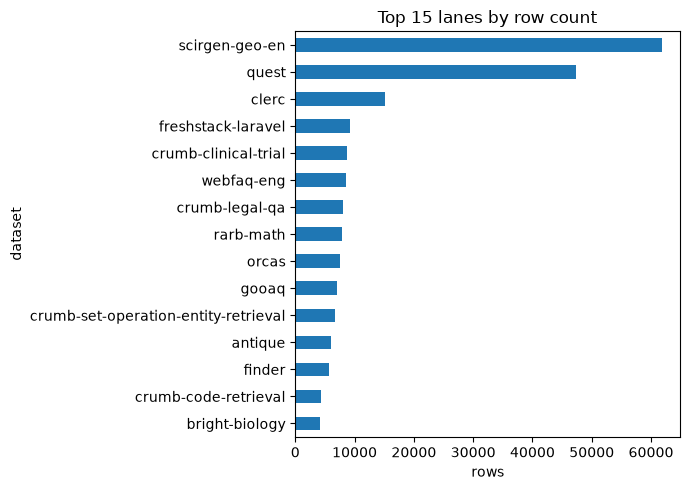

In [3]:
lane_n = lab.groupby("dataset").size().sort_values(ascending=False)
print(f"{len(lane_n)} lanes | top 12 by row count:")
display(lane_n.head(12).rename("rows").to_frame())

by_lane = lab.pivot_table(index="dataset", columns="route", aggfunc="size", fill_value=0)
by_lane["n"] = by_lane.sum(axis=1)
by_lane = by_lane.sort_values("n", ascending=False)
print("dense/sparse/rrf/all_zero counts per lane (top 12):")
display(by_lane.head(12))

ax = lane_n.head(15).iloc[::-1].plot.barh(figsize=(7, 5), title="Top 15 lanes by row count")
ax.set_xlabel("rows"); plt.tight_layout(); plt.show()

## 3 · Dense/sparse distribution

Top-scoring-route mix overall, by source, and by lane. `all_zero` = no route surfaced a
relevant doc (`shape == all_zero`); `all_tied` in the shape table means every route was
acceptable (so the route label is the numeric argmax but the choice is not decisive).

top-scoring-route mix (full union):


,rows,share
route,,
dense_only,126618,0.543
all_zero,46753,0.200
sparse_only,33251,0.143
pure_rrf,26625,0.114


outcome shape (decisiveness):


,rows
shape,
routes_differ,117463
all_tied,69031
all_zero,46753


route mix by source:


route,all_zero,dense_only,pure_rrf,sparse_only
_source,,,,
cascade,14727,52879,10092,13382
v2,3641,9535,1288,1418
v3,16858,11368,2641,4138
v3_aug,11527,52836,12604,14313


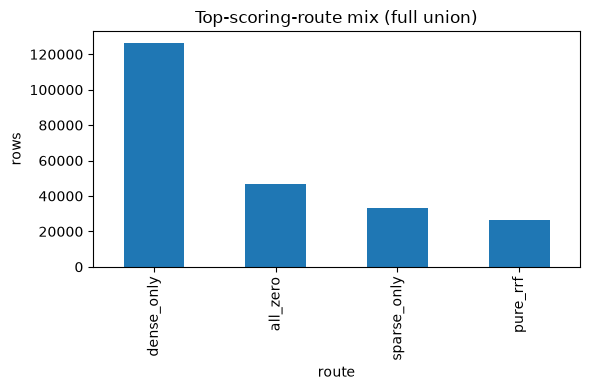

In [4]:
overall = lab["route"].value_counts().rename("rows").to_frame()
overall["share"] = (overall["rows"] / len(lab)).round(3)
print("top-scoring-route mix (full union):")
display(overall)
print("outcome shape (decisiveness):")
display(lab["shape"].value_counts().rename("rows").to_frame())

by_src = lab.pivot_table(index="_source", columns="route", aggfunc="size", fill_value=0)
print("route mix by source:")
display(by_src)

ax = overall["rows"].plot.bar(figsize=(6, 4), title="Top-scoring-route mix (full union)")
ax.set_ylabel("rows"); plt.tight_layout(); plt.show()

## 4 · Cells — archetype coverage

Cells (`composition.cells.CELLS`) select on catalog feature columns, so the union is joined to
the stored catalog. Only catalog-indexed (natural) rows carry features; coverage below is over
that subset, printed as a fraction of the whole union.

catalog-indexed union rows: 125,482/233,247 (53.8%) — cells/taxonomy report over THIS subset
44 cells | 1 empty (0 coverage)


,coverage
multi_statement_context_dump,0.206
deep_nesting_single_sentence,0.154
verbose_grammatical_request,0.117
stopword_saturated_midlength,0.102
wide_flat_enumeration,0.094
high_morphological_variation,0.088
extreme_length_pasted_query,0.081
comparative_multi_entity,0.046
short_grammatical_question,0.037
negation_bearing_question,0.033


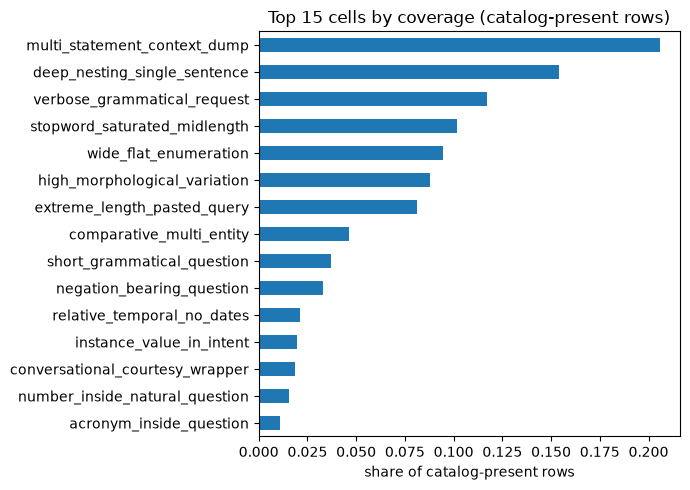

In [5]:
cat = with_derived(pd.read_parquet(DEFAULT_CATALOG)).drop_duplicates(KEY)
feat_cols = [c for c in cat.columns
             if c not in (*KEY, "checkable", "query") and cat[c].dtype != object]
joined = lab[KEY + ["route"]].merge(cat, on=KEY, how="left")
covered = joined[feat_cols].notna().any(axis=1)
print(f"catalog-indexed union rows: {int(covered.sum()):,}/{len(joined):,} "
      f"({covered.mean():.1%}) — cells/taxonomy report over THIS subset")

cov = joined[covered]
cell_cov = (pd.Series({cell.name: float(cell.select(cov).mean()) for cell in CELLS})
            .sort_values(ascending=False))
print(f"{len(CELLS)} cells | {int((cell_cov == 0).sum())} empty (0 coverage)")
display(cell_cov.round(3).rename("coverage").to_frame().head(20))

ax = cell_cov.head(15).iloc[::-1].plot.barh(figsize=(7, 5), title="Top 15 cells by coverage (catalog-present rows)")
ax.set_xlabel("share of catalog-present rows"); plt.tight_layout(); plt.show()

## 5 · Taxonomy features — fire-rates

Fraction of catalog-present rows where each feature column is non-zero. High-fire universal
signals (length, syntactic depth) sit at the top; sparse structural signals (identifiers,
corruption) at the bottom are the discriminating ones.

In [6]:
fire = (cov[feat_cols] != 0).mean().sort_values(ascending=False)
print(f"{len(feat_cols)} catalog feature columns | fire-rate = nonzero share on catalog-present rows:")
display(fire.round(3).rename("fire_rate").to_frame())

83 catalog feature columns | fire-rate = nonzero share on catalog-present rows:


,fire_rate
length.length_chars,1.000
length.length_words,1.000
syntactic_depth.statement_count,1.000
syntactic_depth.nesting_depth,0.994
natural_language_signal.natural_language_share,0.980
...,...
structured_identifiers.academic_identifier,0.000
structured_identifiers.license_plate,0.000
structured_identifiers.cidr,0.000
structured_identifiers.tax_id,0.000


## 6 · Summary & next steps

- **Union:** ~233K rows, 46 lanes; sources v3_aug ≈ cascade ≫ v3 > v2.
- **Dense/sparse:** top-route mix is dense-heavy, with a large `all_zero` tail (no route
  surfaced anything) and a smaller genuine-rrf slice — read alongside the `shape` table, since
  many `all_tied` rows have a numeric argmax but no decisive route.
- **Lanes:** a few lanes (scirgen-geo-en, quest, clerc) dominate the row count; per-lane mix
  varies (some lanes lean far more sparse than the global average).
- **Cells / taxonomy:** reported over the ~54% catalog-indexed rows; a handful of cells carry
  most coverage, and universal features (length, depth) fire everywhere while structural
  identifiers fire rarely — the rare-but-discriminating tail.

**Next steps (not run here):**
- To profile cells/taxonomy over the *full* union (incl. synthetic/aug rows), materialise
  features for the ~46% uncatalogued rows with `FeatureExtractor` (heavy: run offline,
  `engines=(Engine.REGEX,)` for a fast pass) and re-join.
- Cross dense/sparse × cell to see which archetypes are sparse-favouring.